In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks


In [ ]:
# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Cleanly filter and remap labels
footwear_classes = [5, 7, 9]
label_map = {5: 0, 7: 1, 9: 2}

train_mask = np.isin(y_train, footwear_classes)
test_mask  = np.isin(y_test, footwear_classes)

x_train, y_train = x_train[train_mask], y_train[train_mask]
x_test, y_test   = x_test[test_mask],  y_test[test_mask]

# Remap safely (remove any None or invalid entries)
y_train = np.array([label_map[y] for y in y_train if y in label_map])
y_test  = np.array([label_map[y] for y in y_test if y in label_map])

In [ ]:
print("Unique values in y_train:", np.unique(y_train))

Unique values in y_train: [0 1 2]


In [ ]:
# --- Clean None or NaN labels once and for all ---
y_train = np.array([y for y in y_train if y is not None])
y_test  = np.array([y for y in y_test if y is not None])

# Convert to integers
y_train = y_train.astype("int64")
y_test  = y_test.astype("int64")

In [ ]:


# Normalize and reshape for CNN input
x_train_cnn = x_train.astype("float32") / 255.0
x_test_cnn  = x_test.astype("float32") / 255.0
x_train_cnn = np.expand_dims(x_train_cnn, -1)
x_test_cnn  = np.expand_dims(x_test_cnn, -1)

# Flatten for DNN input
x_train_dnn = x_train.reshape(len(x_train), -1) / 255.0
x_test_dnn  = x_test.reshape(len(x_test), -1) / 255.0

print("Training samples:", x_train.shape, " Test samples:", x_test.shape)

Training samples: (18000, 28, 28)  Test samples: (3000, 28, 28)


In [ ]:
# CNN Models
def build_base_cnn():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu', name='dense128')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    return keras.Model(inputs, outputs, name="Base_CNN")

def build_bn_cnn():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    return keras.Model(inputs, outputs, name="BN_CNN")

def build_deep_cnn():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    return keras.Model(inputs, outputs, name="Deep_CNN")

# DNN (Dense Neural Network)
def build_dnn():
    inputs = keras.Input(shape=(784,))
    x = layers.Dense(512, activation='relu')(inputs)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    return keras.Model(inputs, outputs, name="DNN_Flattened")

In [ ]:
# Prepare Models Dictionary

models_dict = {
    "Base_CNN": (build_base_cnn(), x_train_cnn, x_test_cnn),
    "BN_CNN": (build_bn_cnn(), x_train_cnn, x_test_cnn),
    "Deep_CNN": (build_deep_cnn(), x_train_cnn, x_test_cnn),
    "DNN_Flattened": (build_dnn(), x_train_dnn, x_test_dnn)
}

In [ ]:
# Training Setup with Callbacks

checkpoint_cb = callbacks.ModelCheckpoint(
    "best_fmnist_footwear_model.weights.h5",
    save_best_only=True,
    save_weights_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)
earlystop_cb = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

In [ ]:
print("x_train_cnn:", x_train_cnn.shape, x_train_cnn.dtype)
print("x_train_dnn:", x_train_dnn.shape, x_train_dnn.dtype)
print("y_train:", y_train.shape, y_train.dtype)

x_train_cnn: (18000, 28, 28, 1) float32
x_train_dnn: (18000, 784) float64
y_train: (18000,) int64


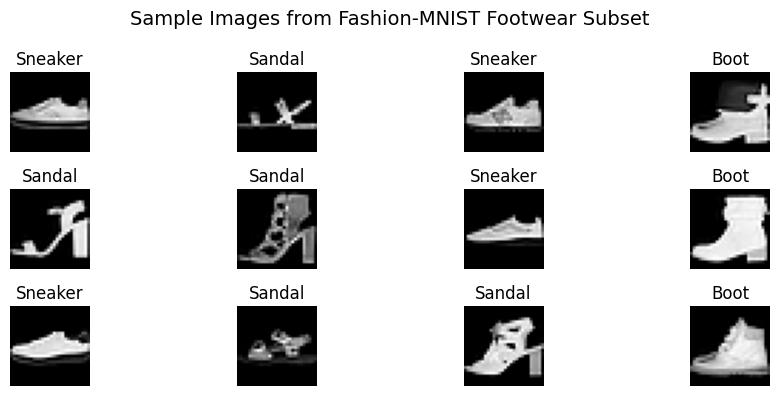

In [ ]:
classes = ["Sandal", "Sneaker", "Boot"]

plt.figure(figsize=(10, 4))

for i in range(12):
    idx = random.randint(0, len(x_train) - 1)
    plt.subplot(3, 4, i+1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(classes[y_train[idx]])
    plt.axis("off")

plt.suptitle("Sample Images from Fashion-MNIST Footwear Subset", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Train All Models and Compare

histories = {}
results = []

# Ensure numeric types before model.fit()
x_train_cnn = np.array(x_train_cnn, dtype="float32")
x_test_cnn  = np.array(x_test_cnn, dtype="float32")

x_train_dnn = np.array(x_train_dnn, dtype="float32")
x_test_dnn  = np.array(x_test_dnn, dtype="float32")

y_train = np.array(y_train, dtype="int64")
y_test  = np.array(y_test, dtype="int64")

for name, (model, X_train, X_test) in models_dict.items():
    print(f"\n🚀 Training {name} ...")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=64,
        validation_split=0.2,
        callbacks=[checkpoint_cb, earlystop_cb],
        verbose=2
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    results.append((name, test_acc))
    histories[name] = history
    print(f" {name} Test Accuracy: {test_acc:.4f}")



🚀 Training Base_CNN ...
Epoch 1/30

Epoch 1: val_accuracy improved from -inf to 0.89833, saving model to best_fmnist_footwear_model.weights.h5
225/225 - 25s - 111ms/step - accuracy: 0.7988 - loss: 0.4996 - val_accuracy: 0.8983 - val_loss: 0.2801
Epoch 2/30

Epoch 2: val_accuracy improved from 0.89833 to 0.90889, saving model to best_fmnist_footwear_model.weights.h5
225/225 - 39s - 171ms/step - accuracy: 0.9024 - loss: 0.2824 - val_accuracy: 0.9089 - val_loss: 0.2588
Epoch 3/30

Epoch 3: val_accuracy improved from 0.90889 to 0.93306, saving model to best_fmnist_footwear_model.weights.h5
225/225 - 42s - 188ms/step - accuracy: 0.9212 - loss: 0.2308 - val_accuracy: 0.9331 - val_loss: 0.1845
Epoch 4/30

Epoch 4: val_accuracy improved from 0.93306 to 0.94083, saving model to best_fmnist_footwear_model.weights.h5
225/225 - 41s - 181ms/step - accuracy: 0.9332 - loss: 0.1938 - val_accuracy: 0.9408 - val_loss: 0.1689
Epoch 5/30

Epoch 5: val_accuracy did not improve from 0.94083
225/225 - 41s -

In [ ]:
print("Train set:", x_train.shape)
print("Validation (split inside fit): 20% of train")
print("External test set:", x_test.shape)

Train set: (18000, 28, 28)
Validation (split inside fit): 20% of train
External test set: (3000, 28, 28)


In [ ]:
# Select and Save Best Model

best_model_name, best_acc = sorted(results, key=lambda x: x[1], reverse=True)[0]
print(f"\n Best model: {best_model_name} (accuracy={best_acc:.4f})")

best_model = models_dict[best_model_name][0]
best_model.save_weights("fmnist_footwear_subnet.weights.h5")
print(" Saved best model weights to fmnist_footwear_subnet.weights.h5")


 Best model: Deep_CNN (accuracy=0.9777)
 Saved best model weights to fmnist_footwear_subnet.weights.h5


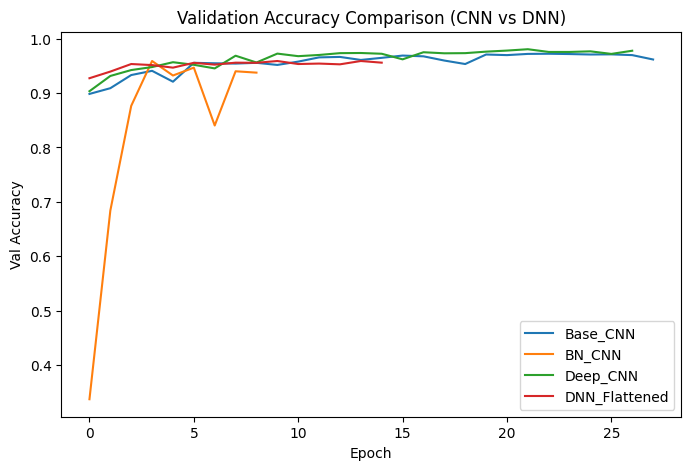

In [ ]:
# Plot Validation Accuracy Comparison

plt.figure(figsize=(8,5))
for name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=f"{name}")
plt.title("Validation Accuracy Comparison (CNN vs DNN)")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np
import random

# Model Comparison Table
results_df = pd.DataFrame(results, columns=["Model", "Test Accuracy"])
results_df = results_df.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

print("\n Model Comparison Table:")
print(results_df.to_string(index=False))

# Highlight the best model
best_model_name = results_df.iloc[0]["Model"]
best_acc = results_df.iloc[0]["Test Accuracy"]
print(f"\n Best Model: {best_model_name} (Accuracy = {best_acc:.4f})")


 Model Comparison Table:
        Model  Test Accuracy
     Deep_CNN       0.977667
     Base_CNN       0.971667
       BN_CNN       0.960667
DNN_Flattened       0.957667

 Best Model: Deep_CNN (Accuracy = 0.9777)


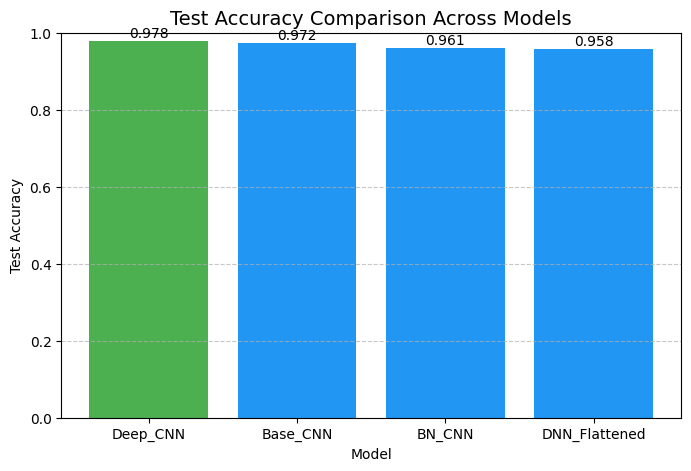

In [ ]:
#  Accuracy Bar Chart
plt.figure(figsize=(8,5))
bars = plt.bar(results_df["Model"], results_df["Test Accuracy"], color=['#4CAF50' if m==best_model_name else '#2196F3' for m in results_df["Model"]])
plt.title("Test Accuracy Comparison Across Models", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.3f}", ha='center', fontsize=10)
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step


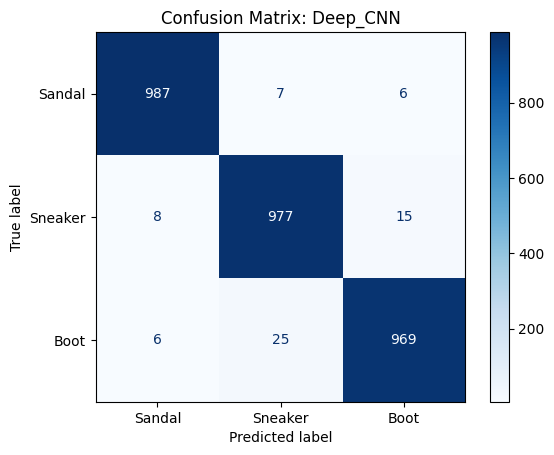


📋 Classification Report for Deep_CNN:

              precision    recall  f1-score   support

      Sandal       0.99      0.99      0.99      1000
     Sneaker       0.97      0.98      0.97      1000
        Boot       0.98      0.97      0.97      1000

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



In [ ]:
# Confusion Matrix and Classification Report for Best Model
best_model = models_dict[best_model_name][0]
X_test = models_dict[best_model_name][2]  # correct test input shape

y_pred_probs = best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sandal", "Sneaker", "Boot"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

print(f"\n📋 Classification Report for {best_model_name}:\n")
print(classification_report(y_test, y_pred, target_names=["Sandal", "Sneaker", "Boot"]))

/tmp/ipython-input-413426928.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-413426928.py:19: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


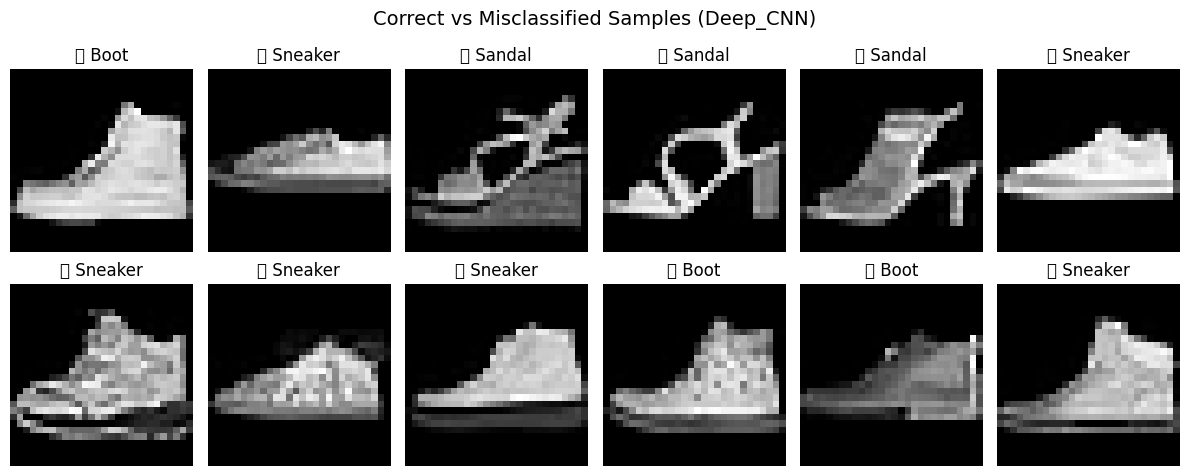

In [ ]:
# Correct vs Misclassified Samples Visualization
correct = np.where(y_pred == y_test)[0]
incorrect = np.where(y_pred != y_test)[0]

plt.figure(figsize=(12, 5))
for i, idx in enumerate(random.sample(list(correct), 6)):
    plt.subplot(2, 6, i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"✅ {['Sandal','Sneaker','Boot'][y_pred[idx]]}")
    plt.axis("off")

for i, idx in enumerate(random.sample(list(incorrect), 6)):
    plt.subplot(2, 6, i+7)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"❌ {['Sandal','Sneaker','Boot'][y_pred[idx]]}")
    plt.axis("off")

plt.suptitle(f"Correct vs Misclassified Samples ({best_model_name})", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Load and filter dataset

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

footwear_classes = [5, 7, 9]
label_map = {5: 0, 7: 1, 9: 2}

train_mask = np.isin(y_train, footwear_classes)
test_mask  = np.isin(y_test, footwear_classes)

x_train, y_train = x_train[train_mask], y_train[train_mask]
x_test, y_test   = x_test[test_mask],  y_test[test_mask]

# Relabel to 0,1,2
y_train = np.array([label_map[y] for y in y_train])
y_test  = np.array([label_map[y] for y in y_test])

print("Original train/test sizes:", x_train.shape, x_test.shape)

Original train/test sizes: (18000, 28, 28) (3000, 28, 28)


In [ ]:
# Merge + 50/50 split

X_all = np.concatenate([x_train, x_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)

x_train, x_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.5,          # 50% test, 50% train
    stratify=y_all,
    random_state=42,
    shuffle=True
)

print("New training set:", x_train.shape, " New test set:", x_test.shape)
print("Class distribution (train):", np.bincount(y_train))
print("Class distribution (test):", np.bincount(y_test))



New training set: (10500, 28, 28)  New test set: (10500, 28, 28)
Class distribution (train): [3500 3500 3500]
Class distribution (test): [3500 3500 3500]


In [ ]:
# Normalize and reshape

x_train_cnn = x_train.astype("float32") / 255.0
x_test_cnn  = x_test.astype("float32") / 255.0
x_train_cnn = np.expand_dims(x_train_cnn, -1)
x_test_cnn  = np.expand_dims(x_test_cnn, -1)

x_train_dnn = x_train.reshape(len(x_train), -1) / 255.0
x_test_dnn  = x_test.reshape(len(x_test), -1) / 255.0

In [ ]:
# Train models

models_dict = {
    "Base_CNN": (build_base_cnn(), x_train_cnn, x_test_cnn),
    "BN_CNN": (build_bn_cnn(), x_train_cnn, x_test_cnn),
    "Deep_CNN": (build_deep_cnn(), x_train_cnn, x_test_cnn),
    "DNN_Flattened": (build_dnn(), x_train_dnn, x_test_dnn)
}

checkpoint_cb = callbacks.ModelCheckpoint(
    "best_fmnist_footwear_model.weights.h5",
    save_best_only=True,
    save_weights_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)
earlystop_cb = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

results = []
histories = {}

for name, (model, X_train, X_test) in models_dict.items():
    print(f"\n🚀 Training {name} ...")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=64,
        validation_split=0.2,
        callbacks=[checkpoint_cb, earlystop_cb],
        verbose=2
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    results.append((name, test_acc))
    histories[name] = history
    print(f" {name} Test Accuracy: {test_acc:.4f}")


🚀 Training Base_CNN ...
Epoch 1/30

Epoch 1: val_accuracy improved from -inf to 0.82714, saving model to best_fmnist_footwear_model.weights.h5
132/132 - 14s - 109ms/step - accuracy: 0.7106 - loss: 0.6667 - val_accuracy: 0.8271 - val_loss: 0.4610
Epoch 2/30

Epoch 2: val_accuracy improved from 0.82714 to 0.86381, saving model to best_fmnist_footwear_model.weights.h5
132/132 - 20s - 154ms/step - accuracy: 0.8508 - loss: 0.3950 - val_accuracy: 0.8638 - val_loss: 0.3732
Epoch 3/30

Epoch 3: val_accuracy improved from 0.86381 to 0.91476, saving model to best_fmnist_footwear_model.weights.h5
132/132 - 13s - 99ms/step - accuracy: 0.8863 - loss: 0.3116 - val_accuracy: 0.9148 - val_loss: 0.2402
Epoch 4/30

Epoch 4: val_accuracy improved from 0.91476 to 0.92571, saving model to best_fmnist_footwear_model.weights.h5
132/132 - 13s - 99ms/step - accuracy: 0.9108 - loss: 0.2566 - val_accuracy: 0.9257 - val_loss: 0.2163
Epoch 5/30

Epoch 5: val_accuracy did not improve from 0.92571
132/132 - 20s - 1

In [ ]:
models_dict = {
    "Base_CNN": (build_base_cnn(), x_train_cnn, x_test_cnn),
    "BN_CNN": (build_bn_cnn(), x_train_cnn, x_test_cnn),
    "Deep_CNN": (build_deep_cnn(), x_train_cnn, x_test_cnn),
    "DNN_Flattened": (build_dnn(), x_train_dnn, x_test_dnn)
}

checkpoint_cb = callbacks.ModelCheckpoint(
    "best_fmnist_footwear_model.weights.h5",
    save_best_only=True,
    save_weights_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)
earlystop_cb = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

results = []
histories = {}

for name, (model, X_train, X_test) in models_dict.items():
    print(f"\n🚀 Training {name} ...")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=64,
        validation_split=0.2,
        callbacks=[checkpoint_cb, earlystop_cb],
        verbose=2
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    results.append((name, test_acc))
    histories[name] = history
    print(f" {name} Test Accuracy: {test_acc:.4f}")



🚀 Training Base_CNN ...
Epoch 1/30

Epoch 1: val_accuracy improved from -inf to 0.85476, saving model to best_fmnist_footwear_model.weights.h5
132/132 - 15s - 113ms/step - accuracy: 0.7246 - loss: 0.6256 - val_accuracy: 0.8548 - val_loss: 0.3849
Epoch 2/30

Epoch 2: val_accuracy improved from 0.85476 to 0.86524, saving model to best_fmnist_footwear_model.weights.h5
132/132 - 12s - 95ms/step - accuracy: 0.8732 - loss: 0.3486 - val_accuracy: 0.8652 - val_loss: 0.3760
Epoch 3/30

Epoch 3: val_accuracy improved from 0.86524 to 0.91238, saving model to best_fmnist_footwear_model.weights.h5
132/132 - 12s - 95ms/step - accuracy: 0.8924 - loss: 0.3136 - val_accuracy: 0.9124 - val_loss: 0.2547
Epoch 4/30

Epoch 4: val_accuracy did not improve from 0.91238
132/132 - 21s - 156ms/step - accuracy: 0.9133 - loss: 0.2530 - val_accuracy: 0.8629 - val_loss: 0.4088
Epoch 5/30

Epoch 5: val_accuracy improved from 0.91238 to 0.92524, saving model to best_fmnist_footwear_model.weights.h5
132/132 - 12s - 9

In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "Test Accuracy"])
results_df = results_df.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
best_model_name = results_df.iloc[0]["Model"]
best_acc = results_df.iloc[0]["Test Accuracy"]

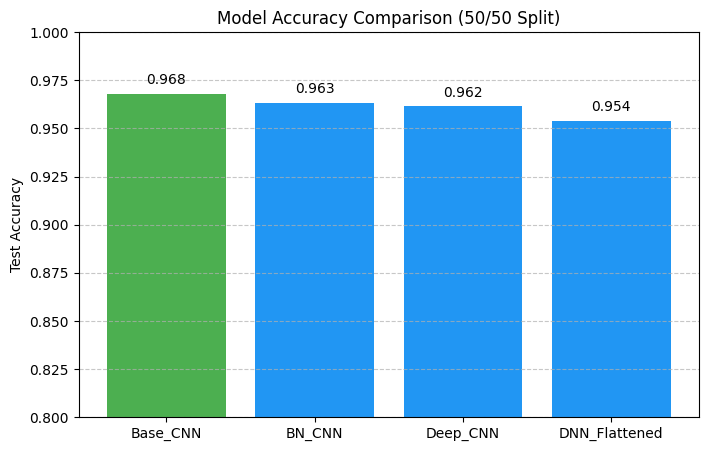

In [ ]:
# Results comparison

plt.figure(figsize=(8,5))
bars = plt.bar(results_df["Model"], results_df["Test Accuracy"],
               color=['#4CAF50' if m==best_model_name else '#2196F3' for m in results_df["Model"]])
plt.title("Model Accuracy Comparison (50/50 Split)")
plt.ylabel("Test Accuracy")
plt.ylim(0.8, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.3f}", ha='center', fontsize=10)
plt.show()

329/329 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step


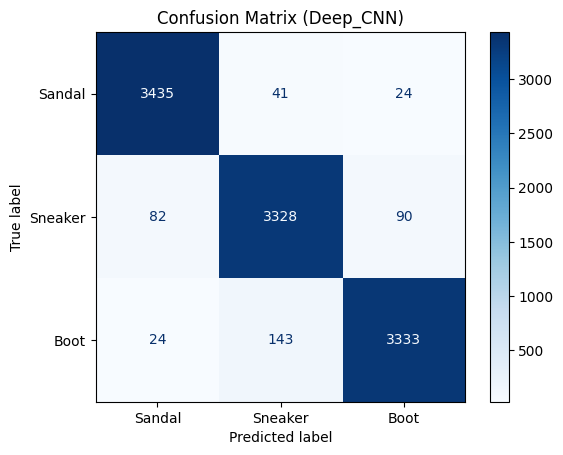


📋 Classification Report (Deep_CNN):

              precision    recall  f1-score   support

      Sandal       0.97      0.98      0.98      3500
     Sneaker       0.95      0.95      0.95      3500
        Boot       0.97      0.95      0.96      3500

    accuracy                           0.96     10500
   macro avg       0.96      0.96      0.96     10500
weighted avg       0.96      0.96      0.96     10500



In [ ]:
# Evaluate best model

best_model = models_dict[best_model_name][0]
X_test = models_dict[best_model_name][2]

y_pred_probs = best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sandal", "Sneaker", "Boot"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix ({best_model_name})")
plt.show()

print(f"\n📋 Classification Report ({best_model_name}):\n")
print(classification_report(y_test, y_pred, target_names=["Sandal", "Sneaker", "Boot"]))

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_acc = results_df.iloc[0]["Test Accuracy"]
best_model = models_dict[best_model_name][0]

In [ ]:
best_model.save_weights(f"{best_model_name}_best_subnet.weights.h5")
print(f" Saved best model weights to {best_model_name}_best_subnet.weights.h5")

 Saved best model weights to Deep_CNN_best_subnet.weights.h5
